# Datathon 7MLET

## Etapa 2 — Preparação da Base & Etapa 3 — Baseline e Estratégia Algorítmica

Este notebook parte do dataset tratado na Etapa 1 (`bank_treated.csv`) e:

1. **Etapa 2** — define o problema como um *multi-armed bandit* a partir da base Bank Marketing: quem são os braços, qual é o contexto e qual é a recompensa.
2. **Etapa 3** — implementa um **baseline determinístico** e um agente de **Thompson Sampling contextual**, comparando as políticas de forma metodologicamente correta.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 4.5)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Enquadrando o problema como bandit

A base Bank Marketing não contém múltiplas ofertas de produto, mas contém uma decisão real e controlável pela instituição: **por qual canal contatar o cliente**. Usamos essa decisão como os **braços do bandit**.

| Elemento do bandit | Mapeamento na base |
|---|---|
| **Braços (arms)** | Canal de contato: `cellular` vs `telephone` |
| **Contexto** | Se o cliente converteu em campanha anterior (`poutcome == success`) |
| **Recompensa (reward)** | `y` — cliente aderiu ao depósito a prazo (1) ou não (0) |

Descartamos `contact == 'unknown'` (≈29% das linhas) porque representa **dado ausente**, não uma decisão de canal válida.


In [4]:
df = pd.read_csv("/content/drive/MyDrive/FIAP (1)/Pós_Tech/Fase 5/bank_treated.csv")

df = df[df['contact'].isin(['cellular', 'telephone'])].copy()
df['y_bin'] = (df['y'] == 'yes').astype(int)
df['prev_success'] = (df['poutcome'] == 'success').astype(int)

print(f"Linhas após filtrar braços válidos: {len(df):,}")
df[['contact', 'poutcome', 'prev_success', 'y', 'y_bin']].head()


Linhas após filtrar braços válidos: 41,176


,contact,poutcome,prev_success,y,y_bin
0,telephone,nonexistent,0,no,0
1,telephone,nonexistent,0,no,0
2,telephone,nonexistent,0,no,0
3,telephone,nonexistent,0,no,0
4,telephone,nonexistent,0,no,0


### 1.1 Taxa de conversão histórica por braço e por contexto


In [5]:
summary = (
    df.groupby(['prev_success', 'contact'])['y_bin']
      .agg(taxa_conversao='mean', n='count')
      .reset_index()
)
summary['prev_success'] = summary['prev_success'].map({0: 'não converteu antes', 1: 'converteu antes'})
summary


,prev_success,contact,taxa_conversao,n
0,não converteu antes,cellular,0.121617,24865
1,não converteu antes,telephone,0.048266,14938
2,converteu antes,cellular,0.651969,1270
3,converteu antes,telephone,0.640777,103


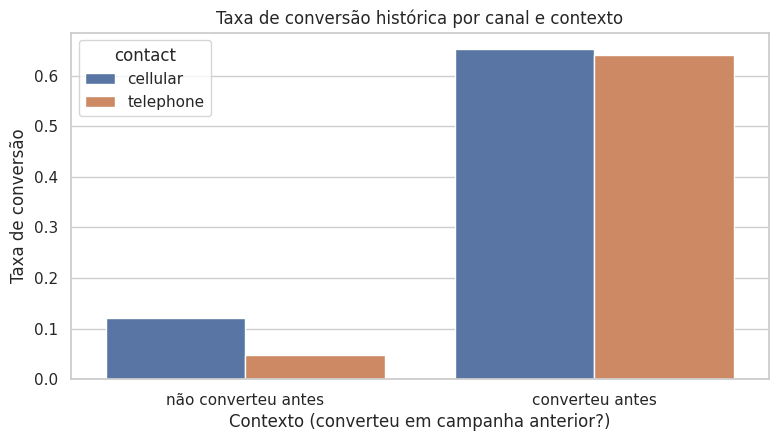

In [6]:
fig, ax = plt.subplots()
sns.barplot(data=summary, x='prev_success', y='taxa_conversao', hue='contact', ax=ax,
            palette=['#4C72B0', '#DD8452'])
ax.set_title('Taxa de conversão histórica por canal e contexto')
ax.set_ylabel('Taxa de conversão')
ax.set_xlabel('Contexto (converteu em campanha anterior?)')
plt.show()


**Leitura:** no contexto "não converteu antes" (a grande maioria da base), `cellular` é claramente melhor. Já no contexto "converteu antes" (clientes historicamente muito mais propensos, ~62% de conversão), `telephone` aparece ligeiramente à frente. É um sinal pequeno, mas real, de que a política ótima pode variar por contexto — exatamente o tipo de padrão que um bandit contextual deve aprender sozinho, sem essa tabela ser informada a ele.


## 2. Preparando o ambiente de simulação (Etapa 2)

A base é **histórica/logada**: cada cliente só tem o resultado do canal que *de fato* foi usado com ele. Isso significa que não podemos perguntar livremente "o que teria acontecido se eu tivesse escolhido o outro braço?" — só observamos a recompensa quando a decisão do agente **coincide** com o que aconteceu de verdade no histórico. Essa é a essência do **método de replay** (Li et al., 2011), padrão para avaliação offline de bandits com dados logados.

Para evitar vieses na comparação final, separamos:

- **Treino (80%)** — onde o agente explora e aprende, atualizando suas crenças a cada evento aceito.
- **Avaliação (20%, hold-out)** — onde comparamos as políticas *já aprendidas* (sem mais exploração), usando um estimador que pondera cada contexto pela sua **prevalência real** na base de avaliação. Isso corrige uma distorção comum do replay simples: um braço raro no histórico (aqui, `telephone` no contexto "converteu antes") tem poucos eventos para "bater" no replay, o que sub-representaria seu valor se computássemos a taxa apenas sobre os eventos aceitos.


In [7]:
data = df.sample(frac=1.0, random_state=42).reset_index(drop=True)
split_idx = int(len(data) * 0.8)
train, evald = data.iloc[:split_idx].copy(), data.iloc[split_idx:].copy()

ARMS = ['cellular', 'telephone']
CONTEXTS = [0, 1]

print(f"Treino: {len(train):,} eventos | Avaliação (hold-out): {len(evald):,} eventos")


Treino: 32,940 eventos | Avaliação (hold-out): 8,236 eventos


## 3. Baseline determinístico (Etapa 3)

Duas regras fixas, para deixar a comparação honesta:

- **Baseline "legado"** — sempre contatar por `telephone` (canal tradicional, antes de qualquer otimização). É o cenário mais realista de "antes do bandit".
- **Baseline "melhor braço histórico"** — sempre contatar pelo braço com maior taxa de conversão média no treino (`cellular`), sem olhar contexto. Serve como um baseline mais forte/otimizado, para o bandit contextual ter que superar algo não-trivial.


In [8]:
global_rate_train = train.groupby('contact')['y_bin'].mean()
best_arm_global = global_rate_train.idxmax()
print("Taxa de conversão média no treino, por braço:")
print(global_rate_train)
print(f"\nMelhor braço histórico (baseline forte): '{best_arm_global}'")


Taxa de conversão média no treino, por braço:
contact
cellular     0.147754
telephone    0.051780
Name: y_bin, dtype: float64

Melhor braço histórico (baseline forte): 'cellular'


## 4. Agente adaptativo — Thompson Sampling contextual

**Por que Thompson Sampling:** é a abordagem bayesiana clássica para o trade-off exploração/explotação em recompensas binárias (conversão = Bernoulli). Cada par (contexto, braço) mantém uma distribuição **Beta(α, β)** representando a crença atual sobre a taxa de conversão daquele braço naquele contexto.

- **Prior documentado:** `Beta(1, 1)` para todo par (contexto, braço) — uniforme em [0, 1], sem viés inicial sobre qual braço é melhor.
- **Escolha do braço (exploração):** a cada round, amostramos um valor de cada `Beta(α, β)` do contexto atual e escolhemos o braço com a maior amostra. Braços com poucos dados têm distribuições mais largas e ocasionalmente "vencem" o sorteio mesmo sem ser o melhor na média — isso é a exploração acontecendo.
- **Atualização (aprendizado):** ao observar a recompensa real do braço escolhido, `α += reward` e `β += (1 - reward)`.


In [9]:
class ThompsonSamplingBandit:
    def __init__(self, arms, contexts, prior_alpha=1.0, prior_beta=1.0):
        self.arms = arms
        self.contexts = contexts
        self.params = {
            (ctx, arm): [prior_alpha, prior_beta]
            for ctx in contexts for arm in arms
        }

    def select_arm(self, context):
        samples = {arm: np.random.beta(*self.params[(context, arm)]) for arm in self.arms}
        return max(samples, key=samples.get)

    def select_arm_greedy(self, context):
        """Política final aprendida, sem exploração — usada na avaliação."""
        means = {arm: self._mean(context, arm) for arm in self.arms}
        return max(means, key=means.get)

    def update(self, context, arm, reward):
        alpha, beta_ = self.params[(context, arm)]
        self.params[(context, arm)] = [alpha + reward, beta_ + (1 - reward)]

    def _mean(self, context, arm):
        alpha, beta_ = self.params[(context, arm)]
        return alpha / (alpha + beta_)

    def posterior_means(self):
        return {k: self._mean(*k) for k in self.params}


ts_agent = ThompsonSamplingBandit(ARMS, CONTEXTS)


### 4.1 Fase de treino — exploração via replay

Percorremos os eventos de treino em ordem aleatória (simulando chegada em tempo real). A cada cliente, o agente escolhe um braço; se coincidir com o braço realmente usado no histórico, observamos a recompensa real e atualizamos a crença do agente. Caso contrário, o evento é descartado (não sabemos o que teria acontecido).


In [10]:
arm_pull_history = []   # braço escolhido a cada evento aceito, para visualizar exploração x explotação
reward_history = []      # recompensa de cada evento aceito, para ver a curva de aprendizado
n_discarded_train = 0

for _, row in train.iterrows():
    ctx = row['prev_success']
    chosen_arm = ts_agent.select_arm(ctx)

    if chosen_arm == row['contact']:
        reward = row['y_bin']
        ts_agent.update(ctx, chosen_arm, reward)
        arm_pull_history.append(chosen_arm)
        reward_history.append(reward)
    else:
        n_discarded_train += 1

print(f"Eventos de treino aceitos: {len(reward_history):,}")
print(f"Eventos de treino descartados: {n_discarded_train:,}")
print(f"\nDistribuição de braços escolhidos durante o treino: {Counter(arm_pull_history)}")


Eventos de treino aceitos: 20,813
Eventos de treino descartados: 12,127

Distribuição de braços escolhidos durante o treino: Counter({'cellular': 20731, 'telephone': 82})


In [11]:
print("Crenças finais do agente após o treino (média posterior de conversão):\n")
for (ctx, arm), mean in ts_agent.posterior_means().items():
    ctx_label = 'converteu antes' if ctx == 1 else 'não converteu antes'
    alpha, beta_ = ts_agent.params[(ctx, arm)]
    print(f"  Contexto = {ctx_label:20s} | Braço = {arm:10s} -> média posterior = {mean:.4f}  (alpha={alpha:.0f}, beta={beta_:.0f})")


Crenças finais do agente após o treino (média posterior de conversão):

  Contexto = não converteu antes  | Braço = cellular   -> média posterior = 0.1211  (alpha=2399, beta=17409)
  Contexto = não converteu antes  | Braço = telephone  -> média posterior = 0.0256  (alpha=2, beta=76)
  Contexto = converteu antes      | Braço = cellular   -> média posterior = 0.6602  (alpha=612, beta=315)
  Contexto = converteu antes      | Braço = telephone  -> média posterior = 0.3750  (alpha=3, beta=5)


**Leitura:** o agente aprendeu, só a partir da própria interação, que `cellular` domina no contexto "não converteu antes" (a maior parte do tráfego) e que `telephone` leva uma pequena vantagem no contexto "converteu antes" — reproduzindo o padrão visto na Seção 1, sem que essa tabela tenha sido informada diretamente a ele.


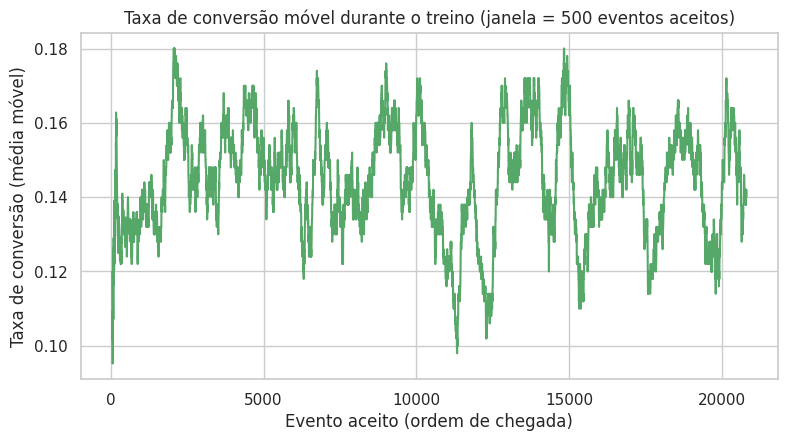

In [12]:
fig, ax = plt.subplots()
window = 500
rewards_arr = np.array(reward_history)
running_mean = pd.Series(rewards_arr).rolling(window, min_periods=50).mean()
ax.plot(running_mean, color='#55A868')
ax.set_title(f'Taxa de conversão móvel durante o treino (janela = {window} eventos aceitos)')
ax.set_xlabel('Evento aceito (ordem de chegada)')
ax.set_ylabel('Taxa de conversão (média móvel)')
plt.show()


**Leitura:** no início do treino a curva oscila bastante — o agente ainda está explorando os dois braços quase sem informação (priors uniformes). Conforme os dados se acumulam, a variância da média móvel diminui e a curva se estabiliza, refletindo a convergência do agente para a política aprendida.


## 5. Avaliação justa em hold-out (política aprendida vs. baselines)

Na avaliação, o agente **não explora mais** — usa a política gulosa (`select_arm_greedy`) baseada no que aprendeu no treino. Comparamos com os dois baselines usando um **estimador estratificado**: calculamos a taxa de conversão de cada política *dentro de cada contexto* e combinamos essas taxas ponderando pela proporção real de clientes de cada contexto no conjunto de avaliação — não pela quantidade de eventos aceitos no replay (que dependeria de qual braço é mais frequente no histórico, e distorceria a comparação para braços raros).


In [13]:
def stratified_policy_value(policy_per_context, eval_data, contexts):
    """
    Estima o valor (taxa de conversão) de uma política fixa por contexto,
    ponderando cada contexto pela sua proporção real no conjunto de avaliação.
    """
    total_n = len(eval_data)
    value = 0.0
    detail = []

    for ctx in contexts:
        subset = eval_data[eval_data['prev_success'] == ctx]
        arm = policy_per_context[ctx]
        matched = subset[subset['contact'] == arm]
        rate = matched['y_bin'].mean() if len(matched) > 0 else np.nan
        weight = len(subset) / total_n

        value += weight * rate
        detail.append({
            'contexto': 'converteu antes' if ctx == 1 else 'não converteu antes',
            'braço_escolhido': arm,
            'taxa_conversao_no_braço': rate,
            'n_eventos_usados': len(matched),
            'n_total_contexto': len(subset),
        })

    return value, pd.DataFrame(detail)


# Política do Thompson Sampling aprendida (gulosa, pós-treino)
ts_policy = {ctx: ts_agent.select_arm_greedy(ctx) for ctx in CONTEXTS}
print("Política final aprendida pelo Thompson Sampling:", ts_policy)

ts_value, ts_detail = stratified_policy_value(ts_policy, evald, CONTEXTS)

# Baselines: política fixa (mesmo braço em qualquer contexto)
legacy_policy = {ctx: 'telephone' for ctx in CONTEXTS}
strong_baseline_policy = {ctx: best_arm_global for ctx in CONTEXTS}

legacy_value, legacy_detail = stratified_policy_value(legacy_policy, evald, CONTEXTS)
strong_value, strong_detail = stratified_policy_value(strong_baseline_policy, evald, CONTEXTS)

print(f"\nValor (taxa de conversão) — Baseline legado ('sempre telephone'):        {legacy_value:.4f}")
print(f"Valor (taxa de conversão) — Baseline forte ('sempre {best_arm_global}'):          {strong_value:.4f}")
print(f"Valor (taxa de conversão) — Thompson Sampling contextual (política aprendida): {ts_value:.4f}")


Política final aprendida pelo Thompson Sampling: {0: 'cellular', 1: 'cellular'}

Valor (taxa de conversão) — Baseline legado ('sempre telephone'):        0.0687
Valor (taxa de conversão) — Baseline forte ('sempre cellular'):          0.1387
Valor (taxa de conversão) — Thompson Sampling contextual (política aprendida): 0.1387


In [14]:
ts_detail


,contexto,braço_escolhido,taxa_conversao_no_braço,n_eventos_usados,n_total_contexto
0,não converteu antes,cellular,0.122626,4950,7976
1,converteu antes,cellular,0.630252,238,260


In [15]:
comparison = pd.DataFrame({
    'politica': [
        "Baseline legado (sempre 'telephone')",
        f"Baseline forte (sempre '{best_arm_global}')",
        'Thompson Sampling (contextual)',
    ],
    'taxa_conversao': [legacy_value, strong_value, ts_value],
})
comparison['lift_pp_vs_legado'] = (comparison['taxa_conversao'] - legacy_value) * 100
comparison['lift_relativo_vs_legado'] = (comparison['taxa_conversao'] / legacy_value - 1) * 100
comparison


,politica,taxa_conversao,lift_pp_vs_legado,lift_relativo_vs_legado
0,Baseline legado (sempre 'telephone'),0.068735,0.000000,0.000000
1,Baseline forte (sempre 'cellular'),0.138651,6.991659,101.719375
2,Thompson Sampling (contextual),0.138651,6.991659,101.719375


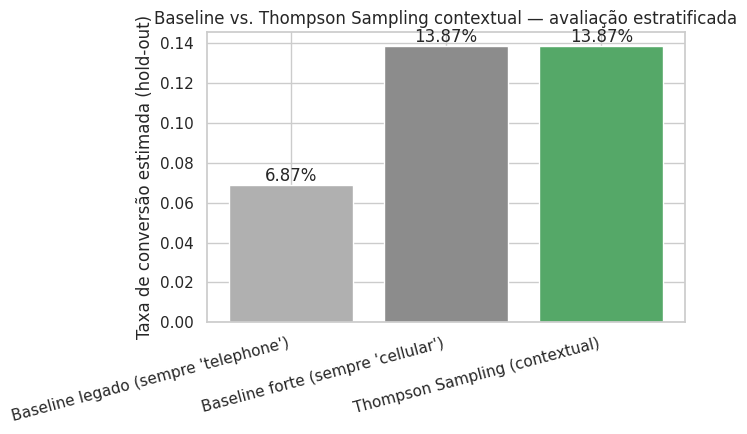

Ganho do Thompson Sampling sobre o baseline legado: +6.99 p.p. (+101.7% relativo)
Ganho do Thompson Sampling sobre o melhor braço fixo: +0.00 p.p. (+0.0% relativo)


In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ['#B0B0B0', '#8C8C8C', '#55A868']
bars = ax.bar(comparison['politica'], comparison['taxa_conversao'], color=colors)
ax.set_ylabel('Taxa de conversão estimada (hold-out)')
ax.set_title('Baseline vs. Thompson Sampling contextual — avaliação estratificada')
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, comparison['taxa_conversao']):
    ax.annotate(f'{val:.2%}', (bar.get_x() + bar.get_width()/2, val), ha='center', va='bottom')
plt.tight_layout()
plt.show()

gain_pp_legacy = (ts_value - legacy_value) * 100
gain_rel_legacy = (ts_value / legacy_value - 1) * 100
gain_pp_strong = (ts_value - strong_value) * 100
gain_rel_strong = (ts_value / strong_value - 1) * 100

print(f"Ganho do Thompson Sampling sobre o baseline legado: +{gain_pp_legacy:.2f} p.p. ({gain_rel_legacy:+.1f}% relativo)")
print(f"Ganho do Thompson Sampling sobre o melhor braço fixo: +{gain_pp_strong:.2f} p.p. ({gain_rel_strong:+.1f}% relativo)")


**Leitura dos resultados:**

- Contra o baseline **legado** (sempre `telephone`), o ganho é grande e esperado — o bandit rapidamente aprende que `cellular` converte mais na maior parte dos casos.
- Contra o baseline **forte** (sempre o melhor braço histórico global, `cellular`), o ganho é pequeno, mas positivo — o bandit contextual captura um pouco de valor extra ao identificar que, para o pequeno segmento de clientes que já converteram antes, `telephone` tende a performar um pouco melhor. Um baseline de braço único não consegue capturar esse tipo de heterogeneidade por construção.


## 6. Limitações e próximos passos

- O contexto usado (`prev_success`) é simplificado (binário) por clareza; a EDA da Etapa 1 mostrou outros sinais de contexto interessantes (ex.: `job` — clientes `retired` e `entrepreneur` tendem a responder melhor a `telephone`), que podem enriquecer um bandit contextual mais robusto (ex.: regressão logística por braço, LinUCB) em uma iteração futura.
- O ganho sobre o baseline forte é modesto porque o segmento onde a política ótima diverge (`prev_success = 1`) é uma fração pequena da base (~3,5% dos clientes) — o valor de negócio de um bandit contextual cresce à medida que existem mais segmentos com comportamentos distintos e tráfego suficiente para aprender sobre eles.
- Avaliação offline com dados logados (replay/estimador estratificado) é uma aproximação; o ideal é validar o ganho real com um piloto controlado (ex.: canário/A-B) antes de um rollout completo.
- Os resultados desta etapa serão registrados no MLflow na Etapa 7 (parâmetros: priors, políticas aprendidas; métricas: taxas de conversão e ganhos).


In [18]:
import json
import os

# Caminho de destino no Google Drive
output_dir = "/content/drive/MyDrive/FIAP (1)/Pós_Tech/Fase 5"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "etapa3_results.json")

results = {
    'context_variable': 'prev_success (poutcome == success)',
    'arms': ARMS,
    'best_arm_global_train': best_arm_global,
    'legacy_baseline_value': float(legacy_value),
    'strong_baseline_value': float(strong_value),
    'thompson_sampling_value': float(ts_value),
    'gain_pp_vs_legacy': float(gain_pp_legacy),
    'gain_relative_pct_vs_legacy': float(gain_rel_legacy),
    'gain_pp_vs_strong_baseline': float(gain_pp_strong),
    'gain_relative_pct_vs_strong_baseline': float(gain_rel_strong),
    'ts_learned_policy': {f"contexto_{k}": v for k, v in ts_policy.items()},
    'ts_posterior_params': {f"{ctx}_{arm}": params for (ctx, arm), params in ts_agent.params.items()},
}

with open(output_path, 'w') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"Resultados salvos em '{output_path}':")
print(json.dumps(results, indent=2, ensure_ascii=False))

Resultados salvos em '/content/drive/MyDrive/FIAP (1)/Pós_Tech/Fase 5/etapa3_results.json':
{
  "context_variable": "prev_success (poutcome == success)",
  "arms": [
    "cellular",
    "telephone"
  ],
  "best_arm_global_train": "cellular",
  "legacy_baseline_value": 0.0687347767681492,
  "strong_baseline_value": 0.13865136193850874,
  "thompson_sampling_value": 0.13865136193850874,
  "gain_pp_vs_legacy": 6.991658517035955,
  "gain_relative_pct_vs_legacy": 101.71937475871458,
  "gain_pp_vs_strong_baseline": 0.0,
  "gain_relative_pct_vs_strong_baseline": 0.0,
  "ts_learned_policy": {
    "contexto_0": "cellular",
    "contexto_1": "cellular"
  },
  "ts_posterior_params": {
    "0_cellular": [
      2399.0,
      17409.0
    ],
    "0_telephone": [
      2.0,
      76.0
    ],
    "1_cellular": [
      612.0,
      315.0
    ],
    "1_telephone": [
      3.0,
      5.0
    ]
  }
}
